In [1]:
import pandas as pd
import numpy as np
import MDAnalysis

import MDAnalysis.analysis.rms
from MDAnalysis.analysis import rms
import seaborn as sns
import matplotlib.pyplot as plt

import os
import tqdm

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#PRE
pre_LC3B_S1=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM1_dt1000.pdb'%prefix_path)
pre_LC3B_S2=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM2_dt1000.pdb'%prefix_path)
pre_LC3B_S3=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM3_dt1000.pdb'%prefix_path)


#UNB
u_unbound_ER_S1 = MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)

#BND
u_bound_ER_S1 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM1_dt1000.pdb"%prefix_path)
u_bound_ER_S2 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM2_dt1000.pdb"%prefix_path)
u_bound_ER_S3 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM3_dt1000.pdb"%prefix_path)





In [3]:
# sb contacts
sb_pairs=[(4,39), (10,36), (48,70)]

def cont_check(Traj,pairs):
    distt_ls=[]
    contact_stat=[]
    contact_count=0
    total_frames=len(Traj.trajectory)

    for t in Traj.trajectory:
        #selecting all the heavy atoms 
        sel1=Traj.select_atoms('resid %d and not type H'%pairs[0])
        sel2=Traj.select_atoms('resid %d and not type H'%pairs[1])
        
        sel1.universe.trajectory[t.frame]
        sel2.universe.trajectory[t.frame]
        
        if len(sel1.residues)==0 or len(sel2.residues)==0:
            contact_occup=0
        else:
            dist_ls=[]
            for i in sel1.atoms:
                for j in sel2.atoms:

                    pos_1=np.array(i.position)  
                    pos_2=np.array(j.position)

                    dist=np.linalg.norm(pos_1 - pos_2)
                    dist_ls.append(dist)
            distt_ls.append(min(dist_ls))
            if np.round(min(dist_ls),1)<=5:
    #             print('contact found at %d'%t.frame)
                contact_stat.append('YES')
                contact_count=contact_count+1
            else:
                contact_stat.append('NO')

        contact_occup=contact_count/total_frames
    #     print('Contact probability b/w %d and %d is %f'%(pairs[0],pairs[1],
    #                                                      contact_occup))
    
    return contact_occup, distt_ls

In [4]:
dist_pre_dat_1=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_pre_dat_1.append(cont_check(pre_LC3B_S1,
                                   pair_)[1])

dist_pre_dat_2=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_pre_dat_2.append(cont_check(pre_LC3B_S2,
                                   pair_)[1])

dist_pre_dat_3=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_pre_dat_3.append(cont_check(pre_LC3B_S3,
                                   pair_)[1])
    
pre_dist_ls=[dist_pre_dat_1[0]+dist_pre_dat_2[0]+dist_pre_dat_3[0], 
dist_pre_dat_1[1]+dist_pre_dat_2[1]+dist_pre_dat_3[1],
dist_pre_dat_1[2]+dist_pre_dat_2[2]+dist_pre_dat_3[2]]

dist_pre_dat_df=pd.DataFrame(pre_dist_ls)
dist_pre_dat_df=dist_pre_dat_df.transpose()
dist_pre_dat_df

100%|████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:17<00:00,  5.87s/it]


,0,1,2
0,5.081775,2.740401,2.780879
1,5.076123,2.770504,2.750019
2,4.511745,3.431705,3.033763
3,3.743057,2.665896,2.502901
4,3.449437,2.649623,2.803513
...,...,...,...
2998,8.859635,4.846865,2.503994
2999,10.159361,5.010879,2.650731
3000,9.201591,2.792170,2.555036
3001,8.266142,4.722065,2.613907


In [5]:
dist_unb_dat_1=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_unb_dat_1.append(cont_check(u_unbound_ER_S1,
                                   pair_)[1])

dist_unb_dat_2=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_unb_dat_2.append(cont_check(u_unbound_ER_S2,
                                   pair_)[1])

dist_unb_dat_3=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_unb_dat_3.append(cont_check(u_unbound_ER_S3,
                                   pair_)[1])
    
unb_dist_ls=[dist_unb_dat_1[0]+dist_unb_dat_2[0]+dist_unb_dat_3[0], 
dist_unb_dat_1[1]+dist_unb_dat_2[1]+dist_unb_dat_3[1],
dist_unb_dat_1[2]+dist_unb_dat_2[2]+dist_unb_dat_3[2]]

dist_unb_dat_df=pd.DataFrame(unb_dist_ls)
dist_unb_dat_df=dist_unb_dat_df.transpose()
dist_unb_dat_df

100%|████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:16<00:00,  5.67s/it]


,0,1,2
0,5.884400,2.734555,2.761324
1,7.938309,3.291254,6.216912
2,8.942975,5.099461,6.435536
3,8.976446,4.660640,4.925620
4,7.914390,4.959613,8.405813
...,...,...,...
2998,12.747714,10.292721,9.157012
2999,13.613719,9.944661,7.969480
3000,12.314620,10.316359,5.145667
3001,11.469776,7.455264,2.830177


In [6]:
dist_bnd_dat_1=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_bnd_dat_1.append(cont_check(u_bound_ER_S1,
                                   pair_)[1])

dist_bnd_dat_2=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_bnd_dat_2.append(cont_check(u_bound_ER_S2,
                                   pair_)[1])

dist_bnd_dat_3=[]
for pair_ in tqdm.tqdm(sb_pairs):
    dist_bnd_dat_3.append(cont_check(u_bound_ER_S3,
                                   pair_)[1])
    
bnd_dist_ls=[dist_bnd_dat_1[0]+dist_bnd_dat_2[0]+dist_bnd_dat_3[0], 
dist_bnd_dat_1[1]+dist_bnd_dat_2[1]+dist_bnd_dat_3[1],
dist_bnd_dat_1[2]+dist_bnd_dat_2[2]+dist_bnd_dat_3[2]]

dist_bnd_dat_df=pd.DataFrame(bnd_dist_ls)
dist_bnd_dat_df=dist_bnd_dat_df.transpose()
dist_bnd_dat_df

100%|████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:17<00:00,  5.87s/it]


,0,1,2
0,5.198542,2.791233,2.686446
1,4.966798,3.801393,4.281697
2,6.748659,4.250763,5.635133
3,5.373957,3.934631,4.949213
4,7.785357,4.646096,6.145971
...,...,...,...
2998,2.679274,7.464848,5.261273
2999,2.654825,7.926824,6.309374
3000,2.700485,6.945168,2.720409
3001,2.757260,7.283368,7.678185


In [7]:
SB_CONT_PAIRS_str=['A_(4,39)', 'B_(10,36)', 'C_(48,70)']

In [8]:
cont_type=[SB_CONT_PAIRS_str[0] for i in dist_pre_dat_df[0]]+[SB_CONT_PAIRS_str[1] for i in dist_pre_dat_df[1]]+\
          [SB_CONT_PAIRS_str[2] for i in dist_pre_dat_df[2]]

dist_all_pre=dist_pre_dat_df[0].to_list()+dist_pre_dat_df[1].to_list()+\
             dist_pre_dat_df[2].to_list()

dist_all_unb=dist_unb_dat_df[0].to_list()+dist_unb_dat_df[1].to_list()+\
             dist_unb_dat_df[2].to_list()


dist_all_bnd=dist_bnd_dat_df[0].to_list()+dist_bnd_dat_df[1].to_list()+\
             dist_bnd_dat_df[2].to_list()

In [9]:
sb_dist_dat_final=pd.DataFrame()
sb_dist_dat_final['PRE']=dist_all_pre
sb_dist_dat_final['UNB']=dist_all_unb
sb_dist_dat_final['PAIR']=cont_type
sb_dist_dat_final

,PRE,UNB,PAIR
0,5.081775,5.884400,"A_(4,39)"
1,5.076123,7.938309,"A_(4,39)"
2,4.511745,8.942975,"A_(4,39)"
3,3.743057,8.976446,"A_(4,39)"
4,3.449437,7.914390,"A_(4,39)"
...,...,...,...
9004,2.503994,9.157012,"C_(48,70)"
9005,2.650731,7.969480,"C_(48,70)"
9006,2.555036,5.145667,"C_(48,70)"
9007,2.613907,2.830177,"C_(48,70)"


In [10]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


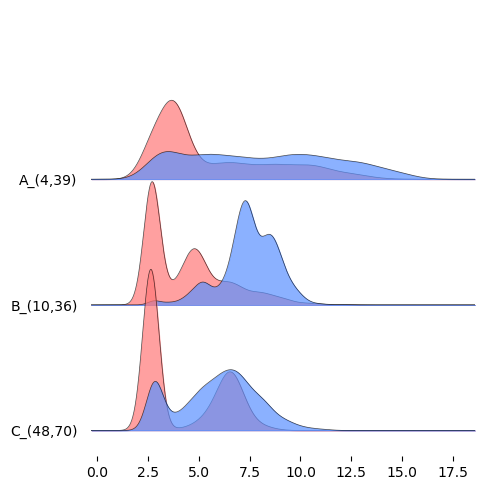

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))


p2=joyplot(
    data=sb_dist_dat_final,
    by="PAIR",
    ylabelsize=10,
    legend=False,
    alpha=0.7,
    
    ax=ax,
    color=['#FF7878','#5A91FF'],
    normalize=False,
    linecolor=None,
    lw=0.5

    
)
ax.set_xlabel('DISTANCE ($\\AA$)')

plt.savefig('../../plots/geometric_analysis/electrostatic_contacts_distance_pre_unb.png', dpi=650,
           bbox_inches='tight',transparent=True)
plt.show()

In [12]:
# PRE vs BND

In [13]:
sb_dist_dat_final_pre_bnd=pd.DataFrame()
sb_dist_dat_final_pre_bnd['PRE']=dist_all_pre
sb_dist_dat_final_pre_bnd['BND']=dist_all_bnd
sb_dist_dat_final_pre_bnd['PAIR']=cont_type
sb_dist_dat_final_pre_bnd

,PRE,BND,PAIR
0,5.081775,5.198542,"A_(4,39)"
1,5.076123,4.966798,"A_(4,39)"
2,4.511745,6.748659,"A_(4,39)"
3,3.743057,5.373957,"A_(4,39)"
4,3.449437,7.785357,"A_(4,39)"
...,...,...,...
9004,2.503994,5.261273,"C_(48,70)"
9005,2.650731,6.309374,"C_(48,70)"
9006,2.555036,2.720409,"C_(48,70)"
9007,2.613907,7.678185,"C_(48,70)"


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


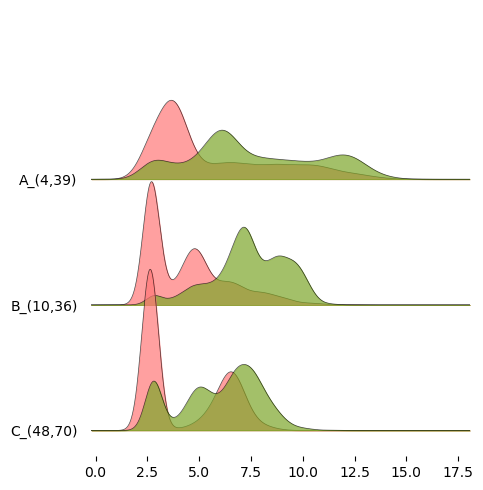

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))


p2=joyplot(
    data=sb_dist_dat_final_pre_bnd,
    by="PAIR",
    ylabelsize=10,
    legend=False,
    alpha=0.7,
    
    ax=ax,
    color=['#FF7878','#7DA629'],
    normalize=False,
    linecolor=None,
    lw=0.5

    
)
ax.set_xlabel('DISTANCE ($\\AA$)')

plt.savefig('../../plots/geometric_analysis/electrostatic_contacts_distance_pre_bnd.png', dpi=650,
           bbox_inches='tight',transparent=True)
plt.show()

In [47]:
FIL_1=sb_dist_dat_final_pre_bnd[sb_dist_dat_final_pre_bnd['PAIR']=="A_(4,39)"]


In [48]:
FIL_1.mode(axis=0, numeric_only=True)

,PRE,BND
0,5.081775,5.198539
1,NaN,5.617659


In [60]:
FIL_1=sb_dist_dat_final_pre_bnd[sb_dist_dat_final_pre_bnd['PAIR']=="A_(4,39)"]
np.percentile(FIL_1["PRE"], [25, 75]), np.percentile(FIL_1["BND"], [25, 75])

(array([3.52716506, 7.50994945]), array([ 5.61878133, 10.20599937]))

In [61]:
FIL_1=sb_dist_dat_final_pre_bnd[sb_dist_dat_final_pre_bnd['PAIR']=="B_(10,36)"]
np.percentile(FIL_1["PRE"], [25, 75]), np.percentile(FIL_1["BND"], [25, 75])

(array([2.69406629, 5.37050295]), array([6.48597026, 8.82511663]))

In [62]:
FIL_1=sb_dist_dat_final_pre_bnd[sb_dist_dat_final_pre_bnd['PAIR']=="C_(48,70)"]
np.percentile(FIL_1["PRE"], [25, 75]), np.percentile(FIL_1["BND"], [25, 75])

(array([2.61292899, 6.32395387]), array([4.64697742, 7.44088006]))